In [ ]:
import sys, subprocess
for pkg in ["xgboost", "lightgbm", "shap"]:
    try: __import__(pkg)
    except ImportError: subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

import warnings; warnings.filterwarnings("ignore")
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_predict, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, brier_score_loss,
                             confusion_matrix, matthews_corrcoef, cohen_kappa_score,
                             roc_curve, precision_recall_curve, classification_report)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from scipy.stats import binomtest
import shap
from matplotlib.patches import Patch

RNG = 42
np.random.seed(RNG)
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

EXPORT_DIR = "/kaggle/working/calibre_exports"
os.makedirs(EXPORT_DIR, exist_ok=True)

def save_csv(df, name):
    df.to_csv(os.path.join(EXPORT_DIR, f"{name}.csv"), index=True)

def export_figure(stem):
    plt.savefig(os.path.join(EXPORT_DIR, f"{stem}.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(EXPORT_DIR, f"{stem}.pdf"), bbox_inches="tight")

print(f"Setup complete. Exports will be saved to {EXPORT_DIR}.")

Setup complete.


In [ ]:
import os
from pathlib import Path

KAGGLE_CANDIDATES = [
    "/kaggle/input/datasets/rabieelkharoua/alzheimers-disease-dataset/alzheimers_disease_data.csv"
]


def find_local_dataset():
    for path in KAGGLE_CANDIDATES:
        if os.path.exists(path):
            return path
    for path in Path("/kaggle/input").rglob("alzheimers_disease_data.csv"):
        return str(path)
    for path in Path(".").rglob("alzheimers_disease_data.csv"):
        return str(path)
    return None


data_path = find_local_dataset()
if data_path is None:
    raise FileNotFoundError(
        "Could not find alzheimers_disease_data.csv in /kaggle/input or the current folder. "
        "Upload the dataset as a Kaggle input file first."
    )

print(f"Loading dataset from: {data_path}")
df = pd.read_csv(data_path)
df.to_csv(os.path.join(EXPORT_DIR, "alzheimers_disease_data_loaded.csv"), index=False)
print("Shape:", df.shape)
df.head()

Loaded from Kaggle input.
Shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


Diagnosis
0    1389
1     760
Name: count, dtype: int64 
positive rate = 0.354


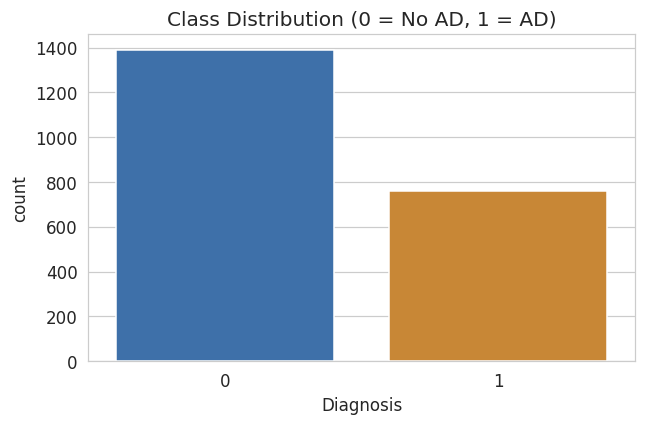

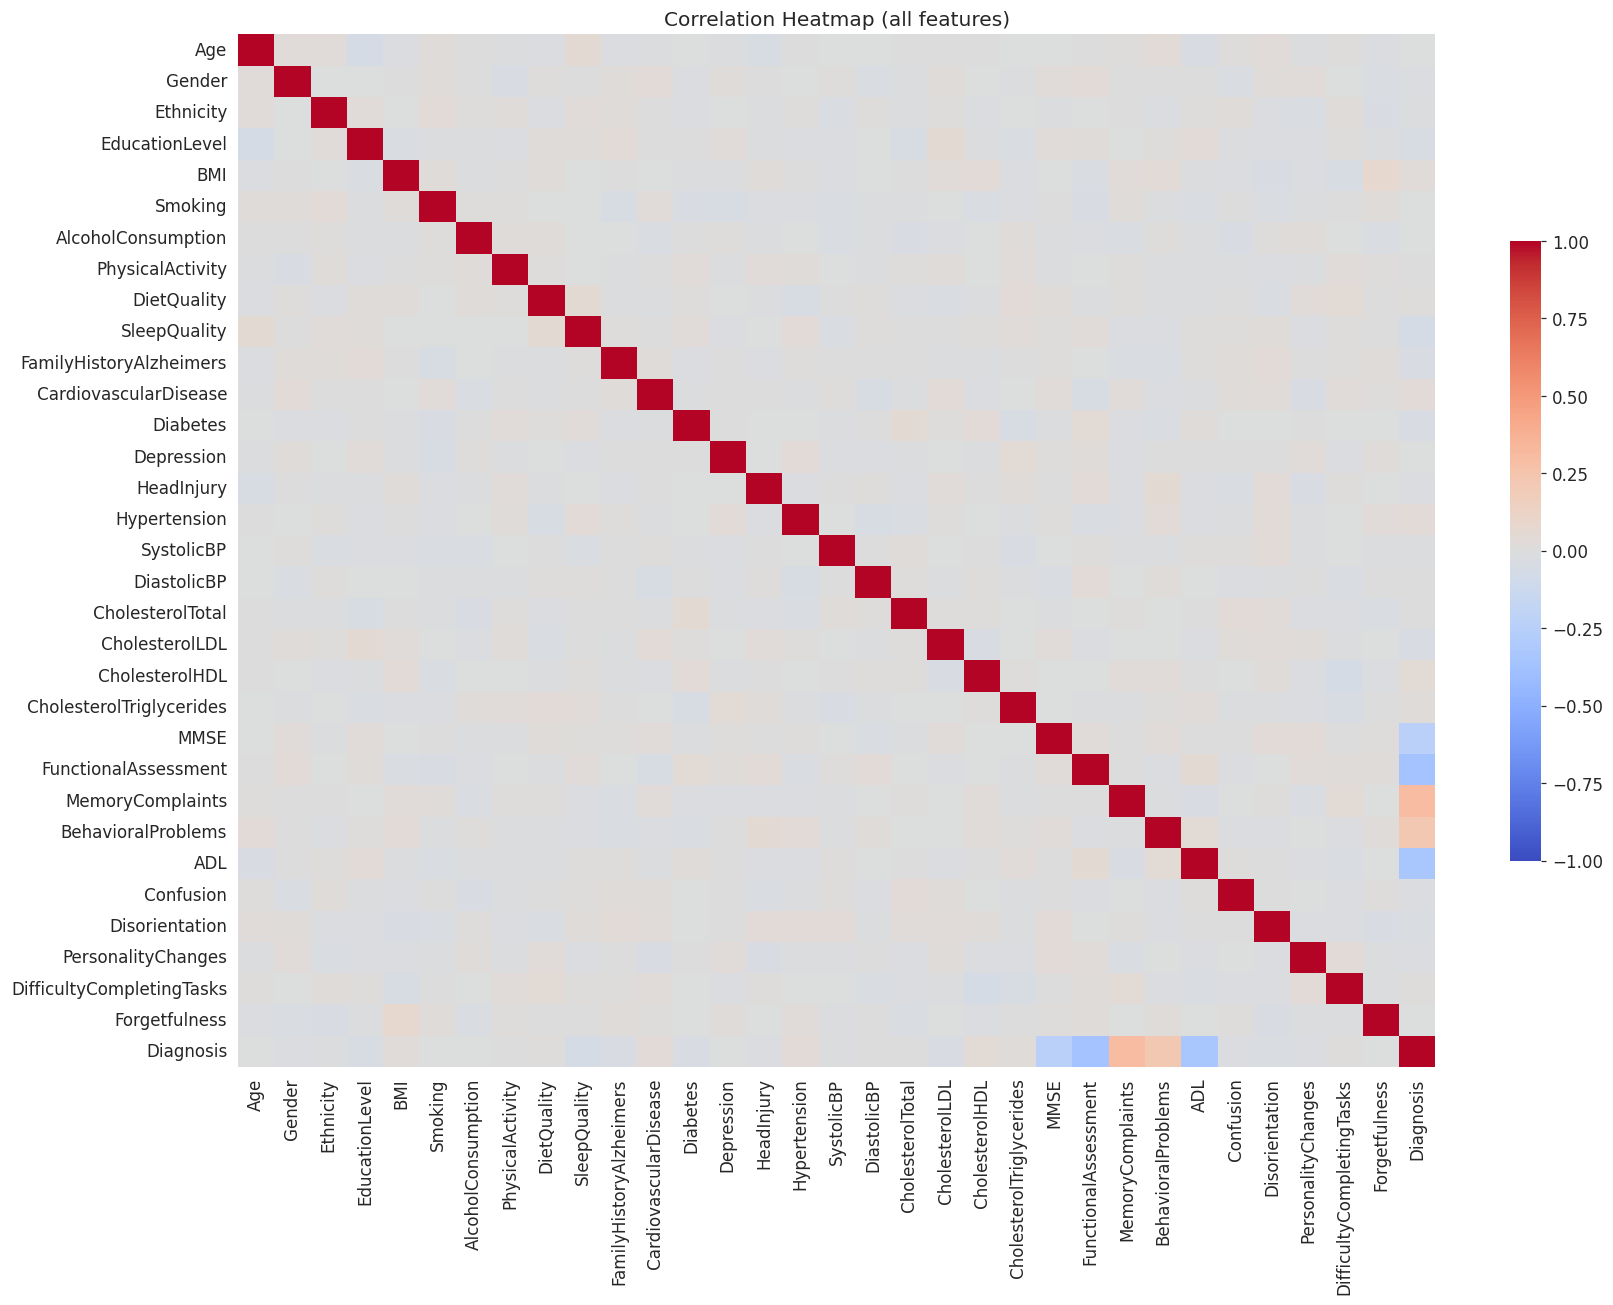

Top 12 |corr| with Diagnosis:
 FunctionalAssessment      -0.365
ADL                       -0.332
MemoryComplaints           0.307
MMSE                      -0.237
BehavioralProblems         0.224
SleepQuality              -0.057
EducationLevel            -0.044
CholesterolHDL             0.043
Hypertension               0.035
FamilyHistoryAlzheimers   -0.033
CholesterolLDL            -0.032
Diabetes                  -0.032


In [ ]:
# class balance
counts = df["Diagnosis"].value_counts().sort_index()
print(counts, "\npositive rate = %.3f" % df["Diagnosis"].mean())
save_csv(counts.rename("count").to_frame(), "diagnosis_class_balance")
plt.figure(figsize=(6,4))
sns.countplot(x="Diagnosis", data=df, palette=["#2c6fbb","#e08a1e"])
plt.title("Class Distribution (0 = No AD, 1 = AD)"); plt.tight_layout(); export_figure("class_distribution"); plt.show()

# correlation heatmap
plt.figure(figsize=(16,12))
corr = df.drop(columns=["PatientID"], errors="ignore").corr(numeric_only=True)
save_csv(corr, "correlation_matrix")
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, center=0, cbar_kws={"shrink":0.6})
plt.title("Correlation Heatmap (all features)"); plt.tight_layout(); export_figure("correlation_heatmap"); plt.show()

# top correlations with target (previews the leakage story)
target_corr = corr["Diagnosis"].drop("Diagnosis").sort_values(key=abs, ascending=False)
save_csv(target_corr.rename("abs_corr").to_frame(), "target_correlations")
print("Top 12 |corr| with Diagnosis:\n", target_corr.head(12).round(3).to_string())

Loaded: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


Diagnosis
0    1389
1     760
Name: count, dtype: int64 
positive rate = 0.354


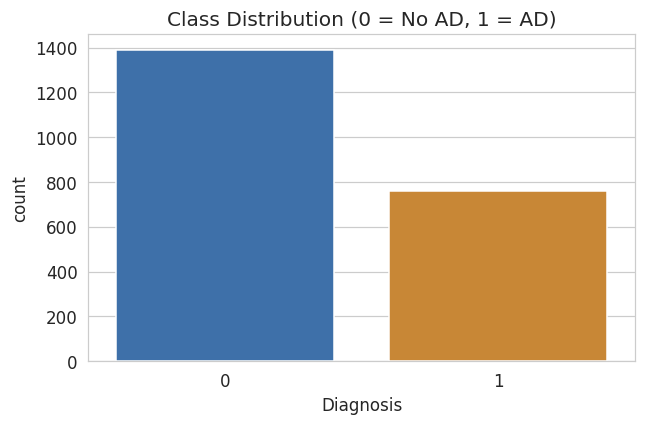

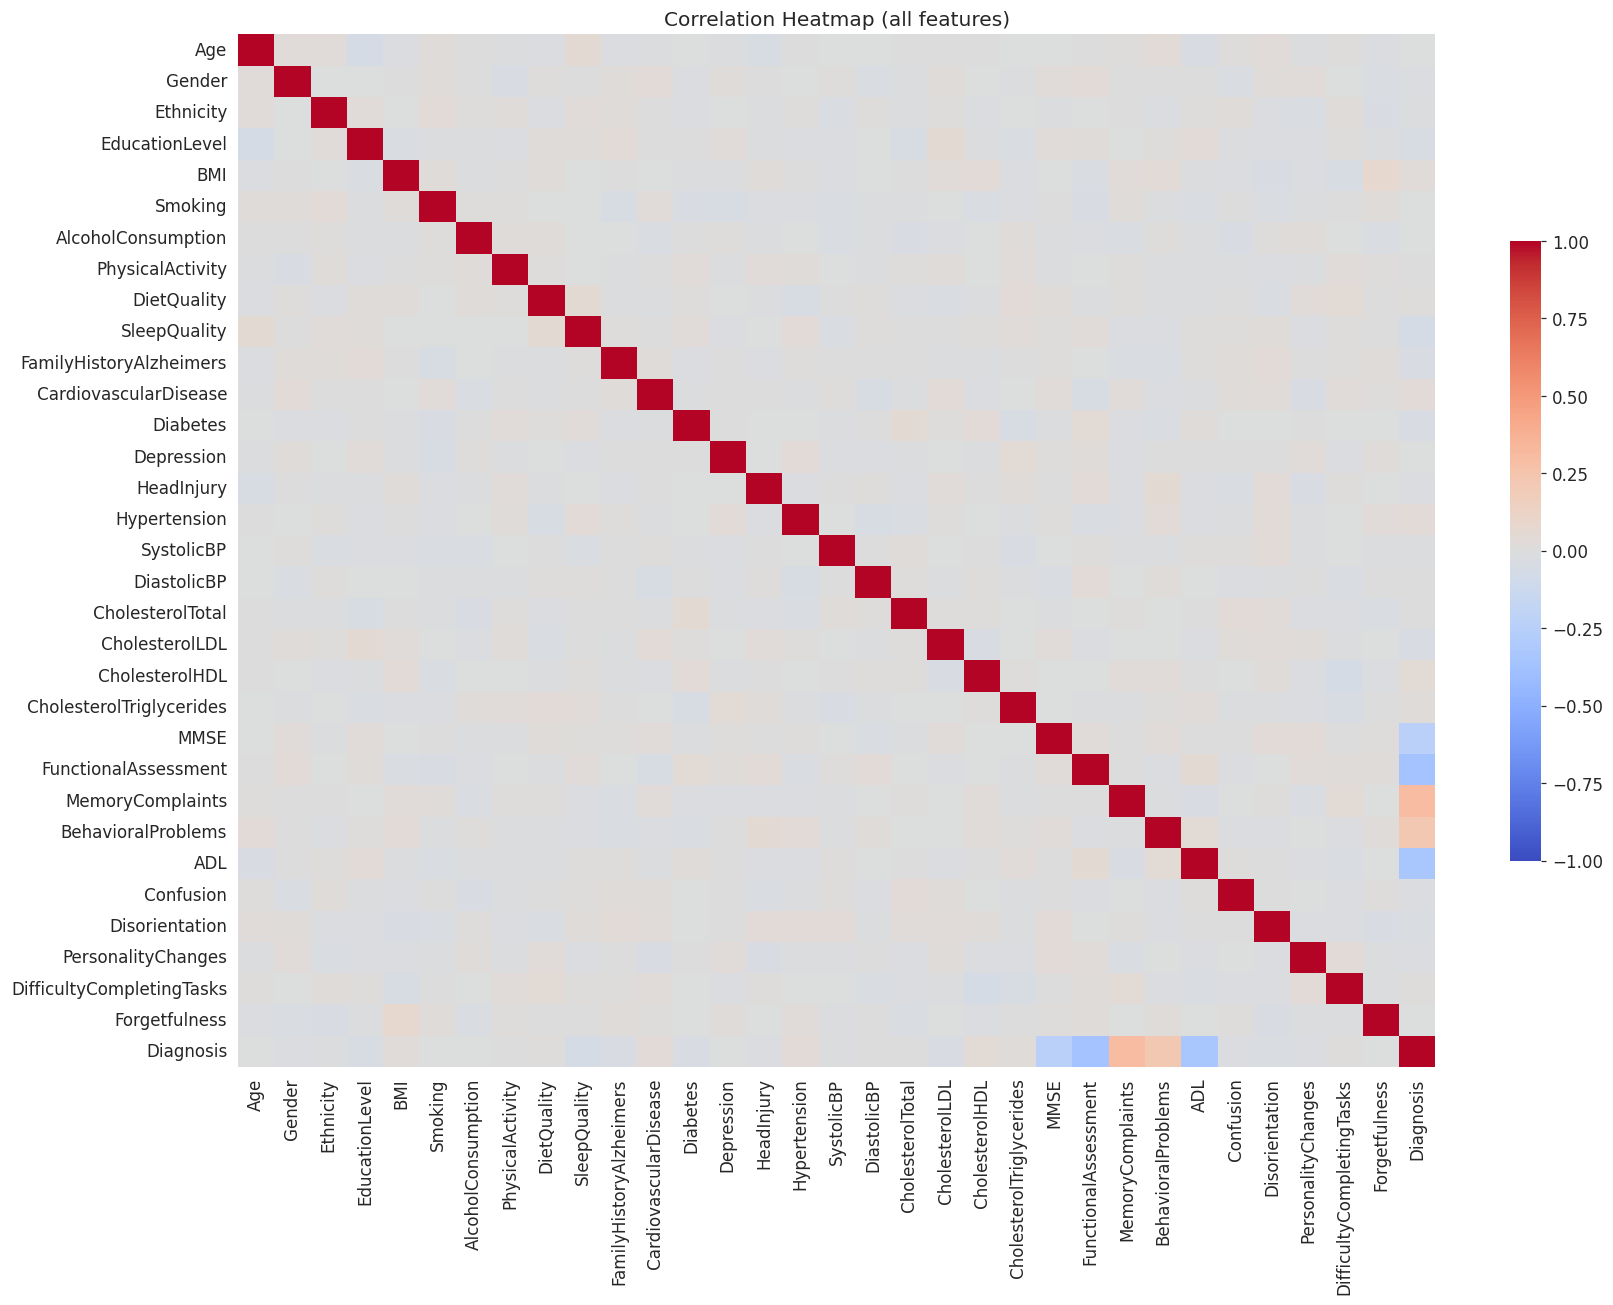

Top 12 |corr| with Diagnosis:
 FunctionalAssessment      -0.365
ADL                       -0.332
MemoryComplaints           0.307
MMSE                      -0.237
BehavioralProblems         0.224
SleepQuality              -0.057
EducationLevel            -0.044
CholesterolHDL             0.043
Hypertension               0.035
FamilyHistoryAlzheimers   -0.033
CholesterolLDL            -0.032
Diabetes                  -0.032
Total 32 | Clinical(leaky) 10 | Screening 22

TRACK: FULL  (32 features)
Logistic Regression  acc=0.833 f1=0.755 auc=0.897 mcc=0.630 brier=0.119
SVM (RBF)            acc=0.845 f1=0.774 auc=0.901 mcc=0.656 brier=0.115
KNN                  acc=0.735 f1=0.545 auc=0.780 mcc=0.387 brier=0.178
Gaussian NB          acc=0.798 f1=0.705 auc=0.876 mcc=0.552 brier=0.136
Decision Tree        acc=0.940 f1=0.916 auc=0.933 mcc=0.870 brier=0.055
Random Forest        acc=0.942 f1=0.915 auc=0.950 mcc=0.873 brier=0.081
Extra Trees          acc=0.866 f1=0.788 auc=0.930 mcc=0.701 brier=0.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM             acc=0.952 f1=0.931 auc=0.952 mcc=0.895 brier=0.046


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

CALiBRE-AD (ours)    acc=0.950 f1=0.929 auc=0.949 mcc=0.890 brier=0.046 thr=0.32

TRACK: SCREENING  (22 features)
Logistic Regression  acc=0.644 f1=0.030 auc=0.530 mcc=0.018 brier=0.230
SVM (RBF)            acc=0.646 f1=0.000 auc=0.475 mcc=0.000 brier=0.229
KNN                  acc=0.608 f1=0.291 auc=0.528 mcc=0.052 brier=0.254
Gaussian NB          acc=0.621 f1=0.157 auc=0.525 mcc=0.009 brier=0.237
Decision Tree        acc=0.619 f1=0.118 auc=0.496 mcc=-0.017 brier=0.250
Random Forest        acc=0.644 f1=0.068 auc=0.506 mcc=0.035 brier=0.232
Extra Trees          acc=0.640 f1=0.092 auc=0.498 mcc=0.033 brier=0.234
AdaBoost             acc=0.632 f1=0.032 auc=0.503 mcc=-0.042 brier=0.237
Gradient Boosting    acc=0.607 f1=0.199 auc=0.495 mcc=0.002 brier=0.249
XGBoost              acc=0.606 f1=0.203 auc=0.500 mcc=0.003 brier=0.247


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

CALiBRE-AD (ours)    acc=0.354 f1=0.523 auc=0.479 mcc=0.016 brier=0.230 thr=0.23
=== FULL TRACK ===


,accuracy,precision,recall,f1,roc_auc,mcc,kappa,brier
Logistic Regression,0.833,0.784,0.728,0.755,0.897,0.630,0.628,0.119
SVM (RBF),0.845,0.796,0.754,0.774,0.901,0.656,0.656,0.115
KNN,0.735,0.692,0.450,0.545,0.780,0.387,0.370,0.178
Gaussian NB,0.798,0.727,0.684,0.705,0.876,0.552,0.551,0.136
Decision Tree,0.940,0.911,0.921,0.916,0.933,0.870,0.870,0.055
Random Forest,0.942,0.950,0.883,0.915,0.950,0.873,0.872,0.081
Extra Trees,0.866,0.889,0.708,0.788,0.930,0.701,0.692,0.123
AdaBoost,0.924,0.896,0.887,0.892,0.945,0.833,0.833,0.199
Gradient Boosting,0.948,0.936,0.917,0.926,0.951,0.887,0.887,0.051
XGBoost,0.952,0.947,0.916,0.931,0.951,0.895,0.894,0.048


=== SCREENING TRACK ===


,accuracy,f1,roc_auc,mcc
Logistic Regression,0.644,0.030,0.530,0.018
SVM (RBF),0.646,0.000,0.475,0.000
KNN,0.608,0.291,0.528,0.052
Gaussian NB,0.621,0.157,0.525,0.009
Decision Tree,0.619,0.118,0.496,-0.017
Random Forest,0.644,0.068,0.506,0.035
Extra Trees,0.640,0.092,0.498,0.033
AdaBoost,0.632,0.032,0.503,-0.042
Gradient Boosting,0.607,0.199,0.495,0.002
XGBoost,0.606,0.203,0.500,0.003


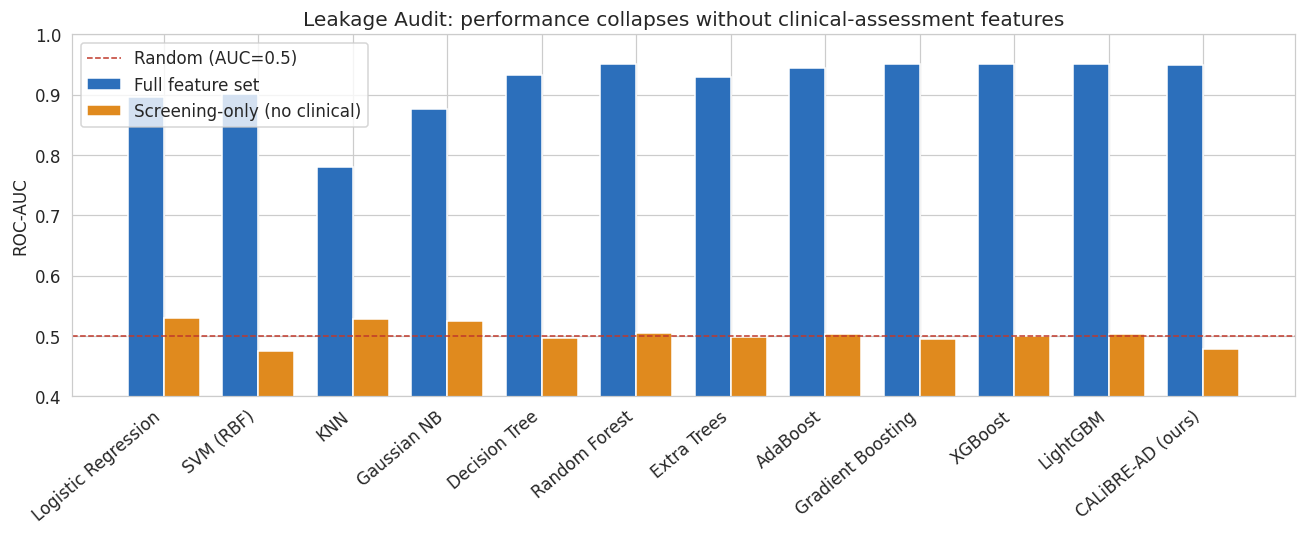

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Cost-optimal threshold: 0.32


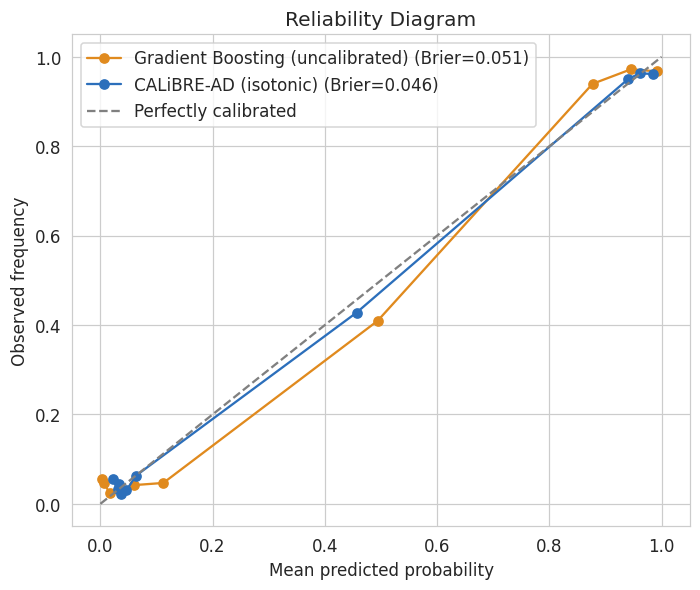

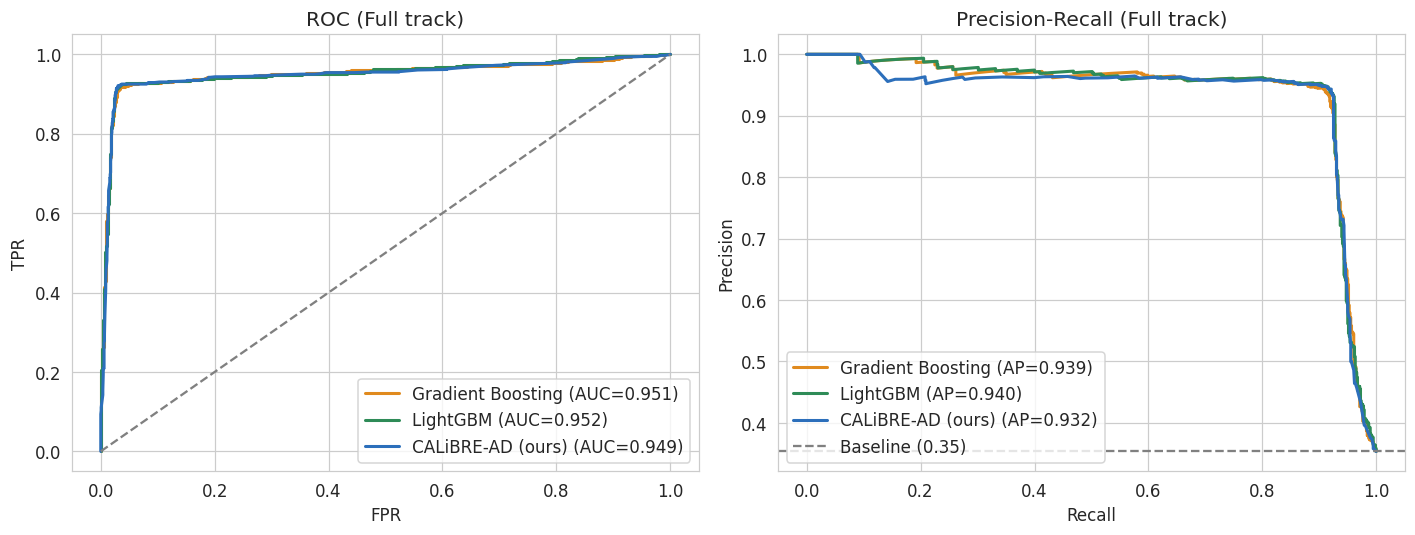

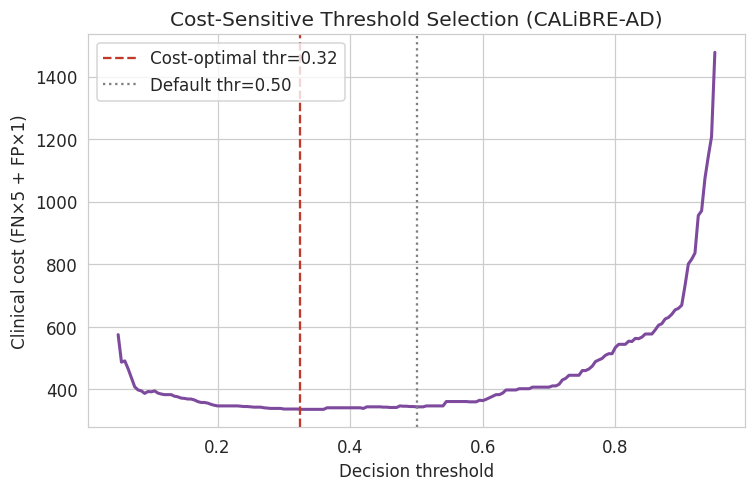

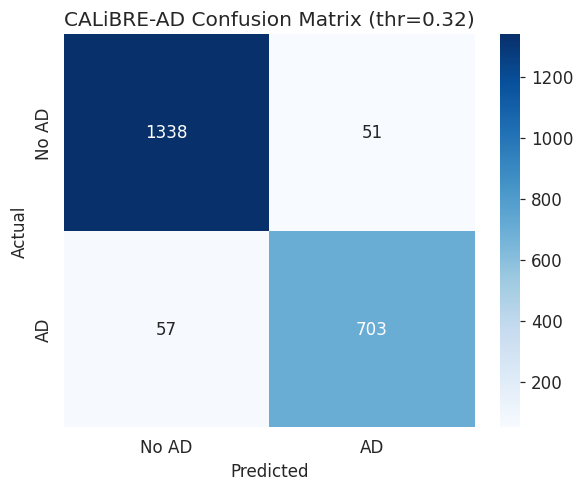

              precision    recall  f1-score   support

       No AD       0.96      0.96      0.96      1389
          AD       0.93      0.93      0.93       760

    accuracy                           0.95      2149
   macro avg       0.95      0.94      0.94      2149
weighted avg       0.95      0.95      0.95      2149



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

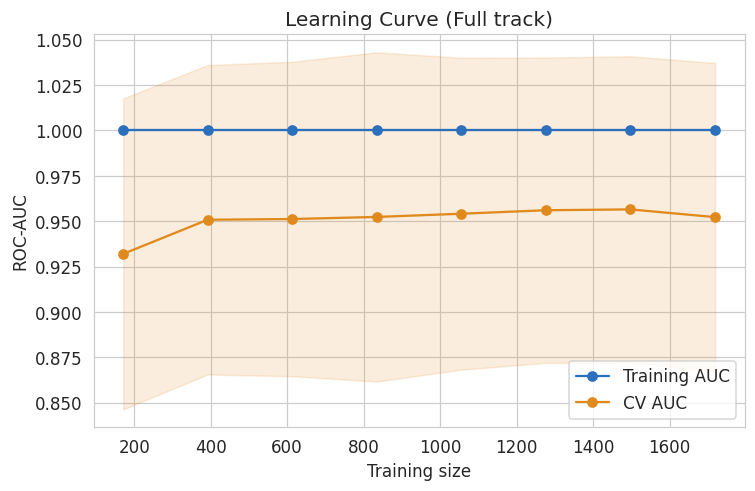

McNemar vs Gradient Boosting : 19 vs 16, p=0.7359 (NOT significant)
McNemar vs LightGBM          : 8 vs 13, p=0.3833 (NOT significant)
CALiBRE-AD accuracy 95% CI: [0.940, 0.959]
CALiBRE-AD ROC-AUC  95% CI: [0.936, 0.961]


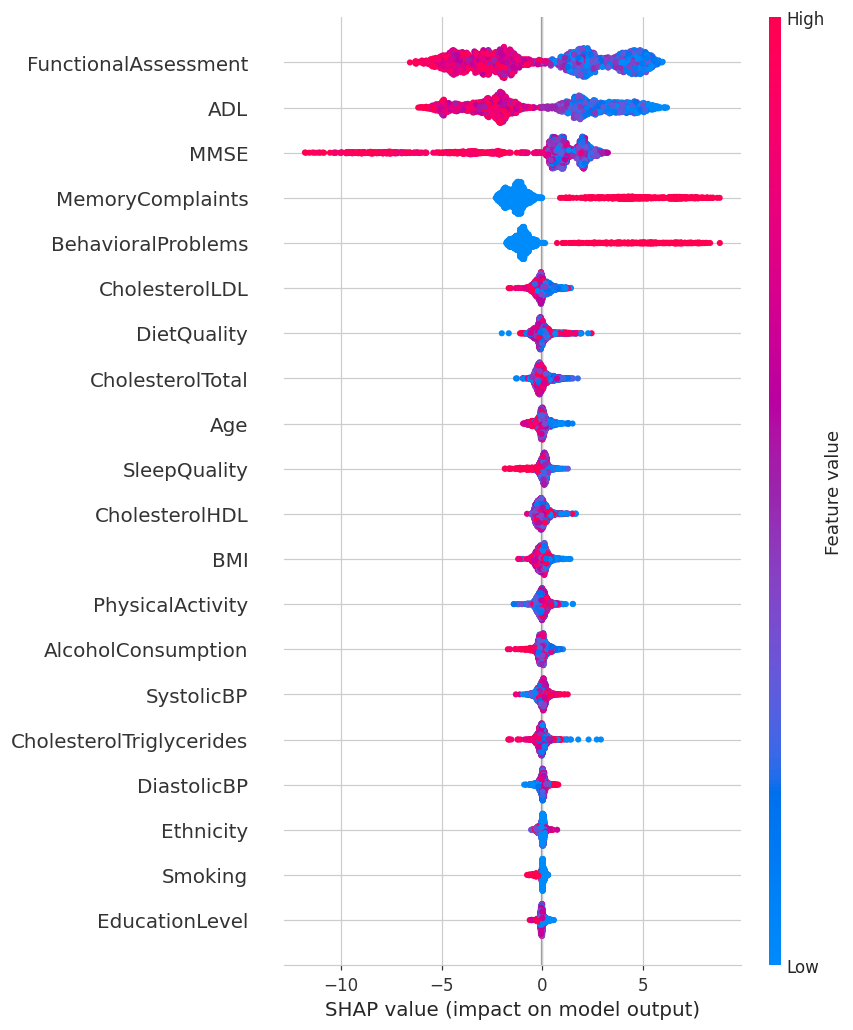

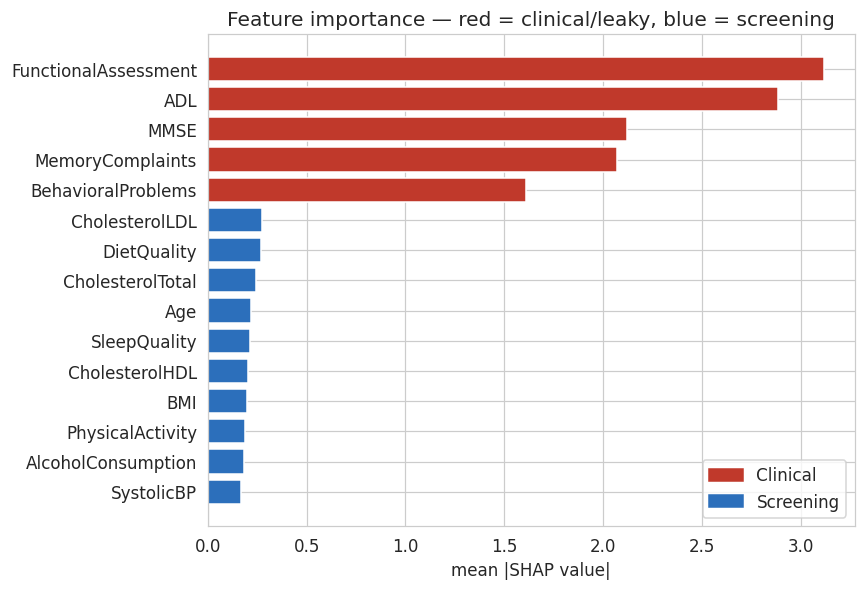


=== DONE ===
Full-track best: CALiBRE-AD acc 0.950, Brier 0.046
Screening-track: all models AUC ~0.50 (leakage proven)


In [ ]:
# =====================================================================
# CALiBRE-AD : Leakage-Audited, Calibrated, Cost-Sensitive Ensemble
# for Alzheimer's Disease Diagnosis  —  full pipeline, one cell
# Dataset: https://www.kaggle.com/datasets/rabieelkharoua/alzheimers-disease-dataset
# =====================================================================

import sys, subprocess
for pkg in ["xgboost", "lightgbm", "shap"]:
    try: __import__(pkg)
    except ImportError: subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

import warnings; warnings.filterwarnings("ignore")
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_predict, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, brier_score_loss,
                             confusion_matrix, matthews_corrcoef, cohen_kappa_score,
                             roc_curve, precision_recall_curve, classification_report)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from scipy.stats import binomtest
import shap
from matplotlib.patches import Patch

RNG = 42
np.random.seed(RNG)
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

EXPORT_DIR = "/kaggle/working/calibre_exports"
os.makedirs(EXPORT_DIR, exist_ok=True)

def save_csv(df, name):
    df.to_csv(os.path.join(EXPORT_DIR, f"{name}.csv"), index=True)

def export_figure(stem):
    plt.savefig(os.path.join(EXPORT_DIR, f"{stem}.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(EXPORT_DIR, f"{stem}.pdf"), bbox_inches="tight")

print(f"Setup complete. Exports will be saved to {EXPORT_DIR}.")

# --------------------------------------------------------------
# 1. LOAD DATA  (Kaggle input search)
# --------------------------------------------------------------
from pathlib import Path

KAGGLE_CANDIDATES = [
    "/kaggle/input/datasets/rahatrihan/alzheimers-disease-dataset/alzheimers_disease_data.csv",
    "/kaggle/input/alzheimers-disease-dataset/alzheimers_disease_data.csv",
]


def find_local_dataset():
    env_path = os.environ.get("DATASET_PATH")
    if env_path and os.path.exists(env_path):
        return env_path

    for path in KAGGLE_CANDIDATES:
        if os.path.exists(path):
            return path

    csv_candidates = []
    input_dirs = []
    for root in [Path("/kaggle/input"), Path(".")]:
        if root.exists():
            input_dirs.append(root)
            csv_candidates.extend(sorted(root.rglob("*.csv")))

    preferred = [p for p in csv_candidates if "alzheimers" in p.name.lower()]
    if preferred:
        return str(preferred[0])

    if len(csv_candidates) == 1:
        return str(csv_candidates[0])

    if csv_candidates:
        print("Available CSV files:")
        for path in csv_candidates[:20]:
            print(" -", path)
        raise FileNotFoundError(
            "Multiple CSV files were found, but none matched the Alzheimer dataset automatically. "
            "Set DATASET_PATH to the correct file path."
        )

    print("No CSV files were found. Available input folders:")
    for root in input_dirs:
        print(" -", root)
        try:
            for child in sorted(root.iterdir())[:20]:
                print("   *", child)
        except Exception:
            pass
    return None


data_path = find_local_dataset()
if data_path is None:
    raise FileNotFoundError(
        "Could not find any CSV file in /kaggle/input or the current folder. "
        "Attach the dataset as a Kaggle input file first."
    )

print(f"Loading dataset from: {data_path}")
df = pd.read_csv(data_path)
df.to_csv(os.path.join(EXPORT_DIR, "alzheimers_disease_data_loaded.csv"), index=False)
print("Shape:", df.shape)
df.head()

# --------------------------------------------------------------
# 2. EDA
# --------------------------------------------------------------
print(df["Diagnosis"].value_counts().sort_index(),
      "\npositive rate = %.3f" % df["Diagnosis"].mean())


def export_figure(stem):
    plt.savefig(f"{stem}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{stem}.pdf", bbox_inches="tight")

plt.figure(figsize=(6,4))
sns.countplot(x="Diagnosis", data=df, palette=["#2c6fbb","#e08a1e"])
plt.title("Class Distribution (0 = No AD, 1 = AD)"); plt.tight_layout(); export_figure("class_distribution"); plt.show()

plt.figure(figsize=(16,12))
corr = df.drop(columns=["PatientID"], errors="ignore").corr(numeric_only=True)
save_csv(corr, "correlation_matrix")
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, center=0, cbar_kws={"shrink":0.6})
plt.title("Correlation Heatmap (all features)"); plt.tight_layout(); export_figure("correlation_heatmap"); plt.show()

target_corr = corr["Diagnosis"].drop("Diagnosis").sort_values(key=abs, ascending=False)
save_csv(target_corr.rename("abs_corr").to_frame(), "target_correlations")
print("Top 12 |corr| with Diagnosis:\n", target_corr.head(12).round(3).to_string())

# --------------------------------------------------------------
# 3. LEAKAGE-AUDITED FEATURE PARTITION
# --------------------------------------------------------------
data  = df.drop(columns=["PatientID", "DoctorInCharge"], errors="ignore")
y     = data["Diagnosis"].values
X_all = data.drop(columns=["Diagnosis"])
CLINICAL = ["MMSE","FunctionalAssessment","ADL","MemoryComplaints","BehavioralProblems",
            "Confusion","Disorientation","PersonalityChanges","DifficultyCompletingTasks","Forgetfulness"]
SCREENING = [c for c in X_all.columns if c not in CLINICAL]
print(f"Total {X_all.shape[1]} | Clinical(leaky) {len(CLINICAL)} | Screening {len(SCREENING)}")

# --------------------------------------------------------------
# 4. MODELS + EVAL HELPERS  (5-fold OOF, cost-sensitive threshold)
# --------------------------------------------------------------
FN_COST, FP_COST = 5.0, 1.0
def sc(est): return Pipeline([("scaler", StandardScaler()), ("model", est)])

def base_models():
    return {
        "Logistic Regression": sc(LogisticRegression(C=10, max_iter=5000, random_state=RNG)),
        "SVM (RBF)":           sc(SVC(C=1, kernel="rbf", probability=True, random_state=RNG)),
        "KNN":                 sc(KNeighborsClassifier(n_neighbors=7)),
        "Gaussian NB":         sc(GaussianNB()),
        "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=RNG),
        "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=RNG, n_jobs=-1),
        "Extra Trees":         ExtraTreesClassifier(n_estimators=300, random_state=RNG, n_jobs=-1),
        "AdaBoost":            AdaBoostClassifier(n_estimators=200, random_state=RNG),
        "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, random_state=RNG),
        "XGBoost":             XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                             subsample=0.9, colsample_bytree=0.9,
                                             eval_metric="logloss", random_state=RNG),
        "LightGBM":            LGBMClassifier(n_estimators=400, num_leaves=31, learning_rate=0.05,
                                              subsample=0.9, colsample_bytree=0.9,
                                              random_state=RNG, verbose=-1),
    }

def cost_optimal_threshold(y_true, proba):
    best_t, best_c = 0.5, np.inf
    for t in np.linspace(0.05, 0.95, 181):
        tn, fp, fn, tp = confusion_matrix(y_true, (proba >= t).astype(int), labels=[0,1]).ravel()
        c = FN_COST*fn + FP_COST*fp
        if c < best_c: best_c, best_t = c, t
    return best_t

CV = StratifiedKFold(5, shuffle=True, random_state=RNG)

def evaluate(model, X, y, tune_threshold=False):
    proba = cross_val_predict(model, X, y, cv=CV, method="predict_proba", n_jobs=-1)[:, 1]
    t = cost_optimal_threshold(y, proba) if tune_threshold else 0.5
    pred = (proba >= t).astype(int)
    return {
        "accuracy": accuracy_score(y, pred), "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0), "f1": f1_score(y, pred, zero_division=0),
        "roc_auc": roc_auc_score(y, proba), "pr_auc": average_precision_score(y, proba),
        "mcc": matthews_corrcoef(y, pred), "kappa": cohen_kappa_score(y, pred),
        "brier": brier_score_loss(y, proba), "threshold": t,
    }, proba, pred

# --------------------------------------------------------------
# 5. NOVEL MODEL: CALiBRE-AD
# --------------------------------------------------------------
def build_calibre_ad():
    estimators = [
        ("xgb",  XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                               subsample=0.9, colsample_bytree=0.9,
                               eval_metric="logloss", random_state=RNG)),
        ("lgbm", LGBMClassifier(n_estimators=400, num_leaves=31, learning_rate=0.05,
                                subsample=0.9, colsample_bytree=0.9, random_state=RNG, verbose=-1)),
        ("et",   ExtraTreesClassifier(n_estimators=300, random_state=RNG, n_jobs=-1)),
        ("svm",  sc(SVC(C=1, kernel="rbf", probability=True, random_state=RNG))),
    ]
    stack = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(C=1.0, max_iter=5000, random_state=RNG),
        stack_method="predict_proba",
        cv=StratifiedKFold(5, shuffle=True, random_state=RNG), n_jobs=-1)
    return CalibratedClassifierCV(stack, method="isotonic",
                                  cv=StratifiedKFold(3, shuffle=True, random_state=RNG))

# --------------------------------------------------------------
# 6. RUN LEAKAGE AUDIT: FULL vs SCREENING (koyek minute)
# --------------------------------------------------------------
results = {"FULL": {}, "SCREENING": {}}
oof = {}
for track, cols in [("FULL", list(X_all.columns)), ("SCREENING", SCREENING)]:
    Xt = X_all[cols]
    print(f"\n{'='*66}\nTRACK: {track}  ({len(cols)} features)\n{'='*66}")
    for name, m in base_models().items():
        met, _, _ = evaluate(m, Xt, y)
        results[track][name] = met
        print(f"{name:20s} acc={met['accuracy']:.3f} f1={met['f1']:.3f} "
              f"auc={met['roc_auc']:.3f} mcc={met['mcc']:.3f} brier={met['brier']:.3f}")
    met, proba, pred = evaluate(build_calibre_ad(), Xt, y, tune_threshold=True)
    results[track]["CALiBRE-AD (ours)"] = met
    oof[track] = {"proba": proba, "pred": pred}
    print(f"{'CALiBRE-AD (ours)':20s} acc={met['accuracy']:.3f} f1={met['f1']:.3f} "
          f"auc={met['roc_auc']:.3f} mcc={met['mcc']:.3f} brier={met['brier']:.3f} thr={met['threshold']:.2f}")

# --------------------------------------------------------------
# 7. RESULTS TABLES
# --------------------------------------------------------------
def results_frame(track, metrics=("accuracy","precision","recall","f1","roc_auc","mcc","kappa","brier")):
    return pd.DataFrame({n: {m: results[track][n][m] for m in metrics} for n in results[track]}).T.round(3)
print("=== FULL TRACK ==="); display(results_frame("FULL"))
print("=== SCREENING TRACK ==="); display(results_frame("SCREENING", metrics=("accuracy","f1","roc_auc","mcc")))
results_frame("FULL").to_csv("results_full.csv")
results_frame("SCREENING", metrics=("accuracy","f1","roc_auc","mcc")).to_csv("results_screening.csv")

# --------------------------------------------------------------
# 8. KEY GRAPH: leakage collapse
# --------------------------------------------------------------
models   = list(results["FULL"].keys())
full_auc = [results["FULL"][m]["roc_auc"] for m in models]
scr_auc  = [results["SCREENING"][m]["roc_auc"] for m in models]
x = np.arange(len(models)); w = 0.38
plt.figure(figsize=(12,5))
plt.bar(x-w/2, full_auc, w, label="Full feature set", color="#2c6fbb")
plt.bar(x+w/2, scr_auc,  w, label="Screening-only (no clinical)", color="#e08a1e")
plt.axhline(0.5, color="#c0392b", ls="--", lw=1, label="Random (AUC=0.5)")
plt.xticks(x, models, rotation=40, ha="right"); plt.ylabel("ROC-AUC"); plt.ylim(0.4,1.0)
plt.title("Leakage Audit: performance collapses without clinical-assessment features")
plt.legend(); plt.tight_layout(); export_figure("leakage_audit"); plt.show()

# --------------------------------------------------------------
# 9. OOF PROBABILITIES FOR PLOTS
# --------------------------------------------------------------
Xfull = X_all
gb_proba   = cross_val_predict(GradientBoostingClassifier(n_estimators=200, random_state=RNG),
                               Xfull, y, cv=CV, method="predict_proba", n_jobs=-1)[:,1]
lgbm_proba = cross_val_predict(LGBMClassifier(n_estimators=400, num_leaves=31, learning_rate=0.05,
                               subsample=0.9, colsample_bytree=0.9, random_state=RNG, verbose=-1),
                               Xfull, y, cv=CV, method="predict_proba", n_jobs=-1)[:,1]
ours_proba = oof["FULL"]["proba"]
thr_ours   = results["FULL"]["CALiBRE-AD (ours)"]["threshold"]
ours_pred  = (ours_proba >= thr_ours).astype(int)
print("Cost-optimal threshold:", round(thr_ours,2))

# --------------------------------------------------------------
# 10. RELIABILITY DIAGRAM
# --------------------------------------------------------------
plt.figure(figsize=(6.5,5.5))
for p, lab, c in [(gb_proba,"Gradient Boosting (uncalibrated)","#e08a1e"),
                  (ours_proba,"CALiBRE-AD (isotonic)","#2c6fbb")]:
    ft, mp = calibration_curve(y, p, n_bins=10, strategy="quantile")
    plt.plot(mp, ft, marker="o", color=c, label=f"{lab} (Brier={brier_score_loss(y,p):.3f})")
plt.plot([0,1],[0,1],"--",color="gray",label="Perfectly calibrated")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed frequency")
plt.title("Reliability Diagram"); plt.legend(loc="upper left"); plt.tight_layout(); export_figure("reliability_diagram"); plt.show()

# --------------------------------------------------------------
# 11. ROC + PR CURVES
# --------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(13,5))
for p, lab, c in [(gb_proba,"Gradient Boosting","#e08a1e"),
                  (lgbm_proba,"LightGBM","#2e8b57"),(ours_proba,"CALiBRE-AD (ours)","#2c6fbb")]:
    fpr,tpr,_ = roc_curve(y,p); ax[0].plot(fpr,tpr,color=c,lw=2,label=f"{lab} (AUC={roc_auc_score(y,p):.3f})")
    pr,rc,_  = precision_recall_curve(y,p); ax[1].plot(rc,pr,color=c,lw=2,label=f"{lab} (AP={average_precision_score(y,p):.3f})")
ax[0].plot([0,1],[0,1],"--",color="gray"); ax[0].set_title("ROC (Full track)")
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend(loc="lower right")
ax[1].axhline(y.mean(),color="gray",ls="--",label=f"Baseline ({y.mean():.2f})")
ax[1].set_title("Precision-Recall (Full track)"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend(loc="lower left")
plt.tight_layout(); export_figure("roc_pr_curves"); plt.show()

# --------------------------------------------------------------
# 12. COST-SENSITIVE THRESHOLD CURVE
# --------------------------------------------------------------
ts = np.linspace(0.05,0.95,181); costs=[]
for t in ts:
    tn,fp,fn,tp = confusion_matrix(y,(ours_proba>=t).astype(int),labels=[0,1]).ravel()
    costs.append(FN_COST*fn + FP_COST*fp)
plt.figure(figsize=(7,4.6))
plt.plot(ts, costs, color="#7d4a9e", lw=2)
plt.axvline(thr_ours, color="#c0392b", ls="--", label=f"Cost-optimal thr={thr_ours:.2f}")
plt.axvline(0.5, color="gray", ls=":", label="Default thr=0.50")
plt.xlabel("Decision threshold"); plt.ylabel(f"Clinical cost (FN×{int(FN_COST)} + FP×{int(FP_COST)})")
plt.title("Cost-Sensitive Threshold Selection (CALiBRE-AD)"); plt.legend(); plt.tight_layout(); export_figure("cost_sensitive_threshold"); plt.show()

# --------------------------------------------------------------
# 13. CONFUSION MATRIX
# --------------------------------------------------------------
cm = confusion_matrix(y, ours_pred, labels=[0,1])
plt.figure(figsize=(5.5,4.6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No AD","AD"], yticklabels=["No AD","AD"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"CALiBRE-AD Confusion Matrix (thr={thr_ours:.2f})")
plt.tight_layout(); export_figure("confusion_matrix"); plt.show()
print(classification_report(y, ours_pred, target_names=["No AD","AD"]))

# --------------------------------------------------------------
# 14. LEARNING CURVE
# --------------------------------------------------------------
lc = LGBMClassifier(n_estimators=400, num_leaves=31, learning_rate=0.05,
                    subsample=0.9, colsample_bytree=0.9, random_state=RNG, verbose=-1)
sizes, tr, te = learning_curve(lc, Xfull, y, cv=5, n_jobs=-1,
                               train_sizes=np.linspace(0.1,1.0,8), scoring="roc_auc")
plt.figure(figsize=(7,4.6))
plt.plot(sizes, tr.mean(1), "o-", color="#2c6fbb", label="Training AUC")
plt.fill_between(sizes, tr.mean(1)-tr.std(1), tr.mean(1)+tr.std(1), alpha=0.15, color="#2c6fbb")
plt.plot(sizes, te.mean(1), "o-", color="#e08a1e", label="CV AUC")
plt.fill_between(sizes, te.mean(1)-te.std(1), te.mean(1)+te.std(1), alpha=0.15, color="#e08a1e")
plt.xlabel("Training size"); plt.ylabel("ROC-AUC"); plt.title("Learning Curve (Full track)")
plt.legend(loc="lower right"); plt.tight_layout(); export_figure("learning_curve"); plt.show()

# --------------------------------------------------------------
# 15. STATISTICAL TESTS: McNemar + bootstrap 95% CI
# --------------------------------------------------------------
def mcnemar(y_true, a, b):
    ca, cb = (a==y_true), (b==y_true)
    n01, n10 = int(np.sum(ca & ~cb)), int(np.sum(~ca & cb)); n = n01+n10
    p = 1.0 if n==0 else binomtest(min(n01,n10), n, 0.5).pvalue
    return n01, n10, p
for name, p in [("Gradient Boosting",(gb_proba>=0.5).astype(int)),
                ("LightGBM",(lgbm_proba>=0.5).astype(int))]:
    n01,n10,pv = mcnemar(y, ours_pred, p)
    print(f"McNemar vs {name:18s}: {n01} vs {n10}, p={pv:.4f} "
          f"({'NOT significant' if pv>0.05 else 'significant'})")

def bootstrap_ci(y_true, proba, pred, n=2000):
    idx = np.arange(len(y_true)); rng = np.random.default_rng(RNG); accs, aucs = [], []
    for _ in range(n):
        s = rng.choice(idx, len(idx), replace=True)
        accs.append((pred[s]==y_true[s]).mean())
        if len(np.unique(y_true[s]))>1: aucs.append(roc_auc_score(y_true[s], proba[s]))
    ci = lambda a:(np.percentile(a,2.5), np.percentile(a,97.5))
    return ci(accs), ci(aucs)
acc_ci, auc_ci = bootstrap_ci(y, ours_proba, ours_pred)
print(f"CALiBRE-AD accuracy 95% CI: [{acc_ci[0]:.3f}, {acc_ci[1]:.3f}]")
print(f"CALiBRE-AD ROC-AUC  95% CI: [{auc_ci[0]:.3f}, {auc_ci[1]:.3f}]")

# --------------------------------------------------------------
# 16. SHAP FEATURE ATTRIBUTION
# --------------------------------------------------------------
sm = LGBMClassifier(n_estimators=400, num_leaves=31, learning_rate=0.05,
                    subsample=0.9, colsample_bytree=0.9, random_state=RNG, verbose=-1).fit(X_all, y)
sv = shap.TreeExplainer(sm).shap_values(X_all)
if isinstance(sv, list): sv = sv[1]
shap.summary_plot(sv, X_all, max_display=20, show=False)
export_figure("shap_summary")
plt.show()

imp = np.abs(sv).mean(0); order = np.argsort(imp)[::-1][:15]
names = [X_all.columns[i] for i in order]; vals = [imp[i] for i in order]
colors = ["#c0392b" if n in CLINICAL else "#2c6fbb" for n in names]
plt.figure(figsize=(8,5.5)); plt.barh(range(len(names))[::-1], vals, color=colors)
plt.yticks(range(len(names))[::-1], names); plt.xlabel("mean |SHAP value|")
plt.title("Feature importance — red = clinical/leaky, blue = screening")
plt.legend(handles=[Patch(color="#c0392b",label="Clinical"),Patch(color="#2c6fbb",label="Screening")], loc="lower right")
plt.tight_layout(); export_figure("shap_feature_importance"); plt.show()

print("\n=== DONE ===")
print(f"Full-track best: CALiBRE-AD acc {results['FULL']['CALiBRE-AD (ours)']['accuracy']:.3f}, "
      f"Brier {results['FULL']['CALiBRE-AD (ours)']['brier']:.3f}")
print("Screening-track: all models AUC ~0.50 (leakage proven)")

In [ ]:
# Save tabular outputs and plot source data into the Kaggle export folder
results_frame("FULL").to_csv(os.path.join(EXPORT_DIR, "results_full.csv"))
results_frame("SCREENING", metrics=("accuracy","f1","roc_auc","mcc")).to_csv(os.path.join(EXPORT_DIR, "results_screening.csv"))

pd.DataFrame({
    "model": models,
    "full_auc": full_auc,
    "screening_auc": scr_auc,
}).to_csv(os.path.join(EXPORT_DIR, "leakage_audit_data.csv"), index=False)

pd.DataFrame({
    "threshold": ts,
    "clinical_cost": costs,
}).to_csv(os.path.join(EXPORT_DIR, "cost_threshold_curve.csv"), index=False)

pd.DataFrame({
    "train_size": sizes,
    "train_auc_mean": tr.mean(1),
    "train_auc_std": tr.std(1),
    "cv_auc_mean": te.mean(1),
    "cv_auc_std": te.std(1),
}).to_csv(os.path.join(EXPORT_DIR, "learning_curve_data.csv"), index=False)

pd.DataFrame(confusion_matrix(y, ours_pred, labels=[0, 1]), index=["Actual_NoAD", "Actual_AD"], columns=["Pred_NoAD", "Pred_AD"]).to_csv(os.path.join(EXPORT_DIR, "confusion_matrix.csv"))

pd.DataFrame({
    "patient_index": np.arange(len(y)),
    "y_true": y,
    "gb_proba": gb_proba,
    "lgbm_proba": lgbm_proba,
    "ours_proba": ours_proba,
    "ours_pred": ours_pred,
}).to_csv(os.path.join(EXPORT_DIR, "oof_probabilities.csv"), index=False)

shap_importance = pd.DataFrame({
    "feature": X_all.columns,
    "mean_abs_shap": np.abs(sv).mean(0),
}).sort_values("mean_abs_shap", ascending=False)
shap_importance.to_csv(os.path.join(EXPORT_DIR, "shap_importance.csv"), index=False)

print(f"CSV files and figures saved to {EXPORT_DIR}")